In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the file generated by run_city_analysis.py
df_res = pd.read_excel("results/Final_Results.xlsx")
df_res.head()

,City,Category,Arr_Corr,Dep_Corr
0,Ostrava_Svinov,Global,0.052416,0.049960
1,Ostrava_Svinov,Regional,0.035235,0.049564
2,Ostrava_Svinov,LongDist,0.044987,0.037048
3,Brno_Main,Global,0.028914,0.079932
4,Brno_Main,Regional,0.026600,0.078818


In [2]:
# We only want to compare Regional vs Long Distance
plot_df = df_res[df_res['Category'].isin(['Regional', 'LongDist'])].copy()

# Rename for nicer labels
plot_df.rename(columns={'Arr_Corr': 'Correlation', 'Category': 'Train Type'}, inplace=True)

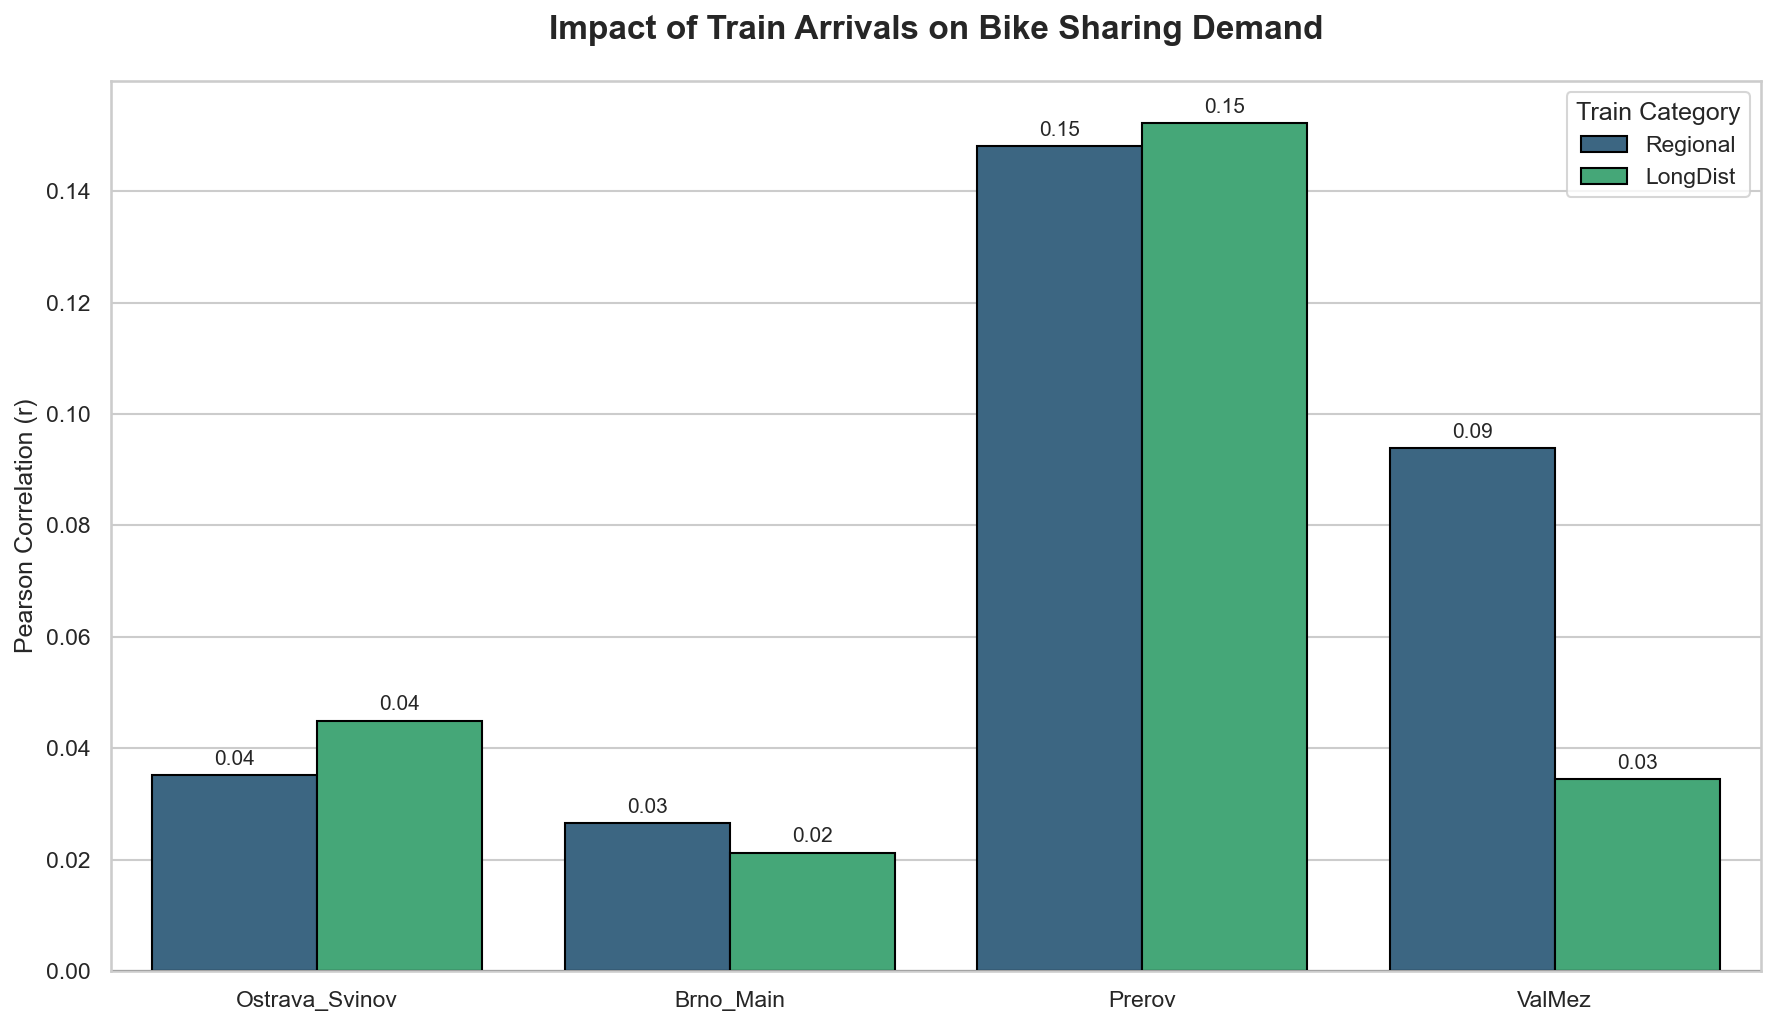

In [3]:
plt.figure(figsize=(12, 7), dpi=150)
sns.set_theme(style="whitegrid")

# Create Bar Chart
ax = sns.barplot(
    data=plot_df,
    x='City',
    y='Correlation',
    hue='Train Type',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Styling
plt.axhline(0, color='black', linewidth=1)
plt.title("Impact of Train Arrivals on Bike Sharing Demand", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Pearson Correlation (r)", fontsize=12)
plt.xlabel("")
plt.legend(title='Train Category', loc='upper right')

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig("Thesis_Chart_Correlation.png")
plt.show()